# Bitcoin Uncertainty Evidence and Calibration

## Role
This notebook evaluates the availability, construction, and calibration of predictive intervals for the final Bitcoin model set.

## Inputs
`results/bitcoin_uncertainty_evidence_v2.csv` (the final unified uncertainty evidence matrix), `results/foundation_uncertainty_summary.csv` (native/calibrated foundation-model coverage and width summary), and `results/foundation_uncertainty_calibration.csv` (per-row native and calibrated interval bounds).

## Outputs
An uncertainty evidence classification, an evidence-availability summary, empirical coverage, nominal coverage error, interval width where methodologically interpretable, and foundation-model calibration evidence.

## Depends On
`07_Bitcoin_Forecast_Freeze_and_Validation.ipynb` and, conceptually, `09_Bitcoin_Robustness_and_Temporal_Stability.ipynb`.

## Authoritative Status
`AUTHORITATIVE UNCERTAINTY EVIDENCE`

## What This Notebook Does Not Do
It does not train models, does not regenerate forecasts, does not invent intervals for models with unavailable evidence, does not treat all uncertainty constructions as equivalent, and does not compute the final Trust Score.

# 1. Objective and Research Question

> How can uncertainty be evaluated honestly when the final Bitcoin forecasting systems have different probabilistic capabilities and therefore provide fundamentally different forms of interval evidence?

Some models produce a native predictive distribution. Some models produce only point forecasts and require an interval to be retrofitted from pre-test residual evidence. Some models have no authoritative uncertainty evidence at all.

> An 80% interval produced natively by a probabilistic foundation model is not methodologically identical to an 80% empirical residual interval constructed after point forecasting, even when both can be scored by empirical coverage.

This distinction is the reason the notebook exists.

# 2. Setup

Standard project-root discovery. Only the frozen uncertainty artifacts, the repository's model display-name mapping, and lightweight pandas/NumPy helpers are loaded -- no forecasting model is loaded and no checkpoint is downloaded.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

# 3. Data and Method

## 3.1 Uncertainty Evidence Taxonomy

### Category A -- Native Foundation Quantiles
Models: **Chronos-Bolt-Tiny**, **TimesFM**. These intervals come directly from the models' native probabilistic/quantile forecast outputs -- verified from `src.bitcoin_uncertainty_calibration`: both models are queried at quantile levels 0.1 and 0.9 for a nominal 80% interval.

### Category B -- Training-Only CQR-Adjusted Foundation Quantiles
Models: **Chronos-Bolt-Tiny**, **TimesFM**. These begin from the native quantiles above and are recalibrated using only a training-only conformal (CQR) calibration window -- verified as 180 training rows ending 2023-08-11 (the day before the final test period starts). Final-test residuals are never used in this adjustment. These are not "native" outputs once calibrated; the calibration is applied post-hoc.

### Category C -- Validation-Residual Empirical Intervals
Models: **Naive**, **7-Day Moving Average**, **ARIMA Rolling One-Step**, **Simple Exponential Smoothing**, **Additive-Trend Exponential Smoothing**, **Persistence-Enhanced Log-Return Transformer**. Verified from `tools/rebuild_bitcoin_domain.py`: for each model, absolute residuals are computed on that model's own forecast over the **final 1,061 training-period dates** (a training-only validation window, disjoint from the test period); the interval radius is the training-residual quantile at the nominal level, and the resulting interval is symmetric around the test-period point forecast (width = 2 x radius).

> These intervals are not native probabilistic outputs of the forecasting model. They are post-hoc empirical uncertainty bands derived from held-out pre-test residual behaviour.

### Category D -- Unavailable
Models: **Persistence-Enhanced Log-Return LSTM**, **Prophet -- 30-Day Periodic Refit**. Confirmed from `bitcoin_uncertainty_evidence_v2.csv`: both are recorded as `Unavailable`, not `Poor`, `Zero`, or `Failed`, and no interval is fabricated for either.

In [2]:
taxonomy_table = pd.DataFrame([
    {'Evidence Type': 'Native Foundation Quantiles', 'Models': 'Chronos-Bolt-Tiny, TimesFM',
     'Source': 'Native model quantile output (0.1/0.9 levels)', 'Native Model Property?': 'Yes',
     'Calibration Source': 'None', 'Comparable Widths With': 'Same native-method family only'},
    {'Evidence Type': 'CQR-Adjusted Foundation Quantiles', 'Models': 'Chronos-Bolt-Tiny, TimesFM',
     'Source': 'Native quantiles + training-only conformal adjustment', 'Native Model Property?': 'Derived from native',
     'Calibration Source': 'Training-only (180 rows ending 2023-08-11)', 'Comparable Widths With': 'Same calibrated-method family'},
    {'Evidence Type': 'Validation-Residual Empirical Interval', 'Models': 'Naive, 7-Day Moving Average, ARIMA Rolling One-Step, Simple Exponential Smoothing, Additive-Trend Exponential Smoothing, Persistence-Enhanced Log-Return Transformer',
     'Source': 'Symmetric radius from training-validation absolute-residual quantiles', 'Native Model Property?': 'No',
     'Calibration Source': 'Final 1,061 training dates', 'Comparable Widths With': 'Other empirical intervals, cautiously'},
    {'Evidence Type': 'Unavailable', 'Models': 'Persistence-Enhanced Log-Return LSTM, Prophet — 30-Day Periodic Refit',
     'Source': 'N/A', 'Native Model Property?': 'N/A', 'Calibration Source': 'N/A', 'Comparable Widths With': 'N/A'},
]).set_index('Evidence Type')
taxonomy_table

,Models,Source,Native Model Property?,Calibration Source,Comparable Widths With
Evidence Type,,,,,
Native Foundation Quantiles,"Chronos-Bolt-Tiny, TimesFM",Native model quantile output (0.1/0.9 levels),Yes,None,Same native-method family only
CQR-Adjusted Foundation Quantiles,"Chronos-Bolt-Tiny, TimesFM",Native quantiles + training-only conformal adj...,Derived from native,Training-only (180 rows ending 2023-08-11),Same calibrated-method family
Validation-Residual Empirical Interval,"Naive, 7-Day Moving Average, ARIMA Rolling One...",Symmetric radius from training-validation abso...,No,"Final 1,061 training dates","Other empirical intervals, cautiously"
Unavailable,"Persistence-Enhanced Log-Return LSTM, Prophet ...",N/A,N/A,N/A,N/A


## 3.2 Comparability Principle

> Coverage can be reported across evidence types because it measures whether realised observations fall inside the stated nominal interval. Interval width, however, must not be interpreted as directly comparable across fundamentally different interval-construction methods without an explicit methodological justification.

Rules followed throughout this notebook:

1. Native foundation intervals are compared with native foundation intervals.
2. CQR-adjusted foundation intervals are compared with other CQR-adjusted foundation intervals.
3. Validation-residual empirical intervals are interpreted as retrospective empirical evidence.
4. Models with unavailable evidence remain absent rather than being assigned artificial values.
5. Cross-method width rankings are not treated as universal uncertainty-quality rankings.

## 3.3 Evaluation Metrics

**Nominal coverage**: the interval's stated target probability -- 0.80 for every model in this notebook (the empirical-residual models additionally have 0.95 evidence, foundation models only have 0.80; see Limitations, Section 8).

**Empirical coverage**: `Coverage = (1/N) * sum_t 1(L_t <= y_t <= U_t)` -- the observed fraction of test targets falling inside the stated interval.

**Coverage error**: `Coverage Error = |Coverage - Nominal|`.

**Average interval width**: `Average Width = (1/N) * sum_t (U_t - L_t)`.

Lower coverage error is preferable. Narrower intervals are not automatically better -- a narrow, badly under-covering interval is worse evidence than a wider, well-calibrated one; width must always be interpreted subject to adequate calibration (Section 3.2). This notebook does not fabricate proper scoring rules (e.g. pinball/CRPS loss): the exact per-day lower/upper interval vectors needed for such scoring are not preserved as artifacts for the validation-residual methods, only the resulting scalar radius/width -- so only coverage, coverage error, and average width are reported here.

# 4. Full Uncertainty Evidence

## 4.1 Unified Evidence Table

> The table below inventories every final Bitcoin model and records exactly what uncertainty evidence is available, how it was constructed, and what calibration evidence can legitimately be interpreted.

In [3]:
uncertainty = pd.read_csv(ROOT / 'results' / 'bitcoin_uncertainty_evidence_v2.csv')

display_evidence = uncertainty.copy()
display_evidence['Coverage'] = display_evidence['Coverage'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'Unavailable')
display_evidence['Average Width'] = display_evidence['Average Width'].map(lambda x: f'{x:,.2f}' if pd.notna(x) else 'Unavailable')
display_evidence['Coverage Error'] = display_evidence['Coverage Error'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'Unavailable')
display_evidence['Calibration Source'] = display_evidence['Calibration Source'].fillna('None')

display_evidence[[
    'Model', 'Uncertainty Evidence Type', 'Nominal Level', 'Coverage',
    'Average Width', 'Coverage Error', 'Calibration Source', 'Evidence Status',
]]

,Model,Uncertainty Evidence Type,Nominal Level,Coverage,Average Width,Coverage Error,Calibration Source,Evidence Status
0,Naive,Validation-Residual Empirical Interval,0.80,0.6569,"2,766.58",0.1431,"Final 1,061 training dates",Available
1,Naive,Validation-Residual Empirical Interval,0.95,0.9039,"5,985.98",0.0461,"Final 1,061 training dates",Available
2,7-Day Moving Average,Validation-Residual Empirical Interval,0.80,0.6673,"5,119.61",0.1327,"Final 1,061 training dates",Available
3,7-Day Moving Average,Validation-Residual Empirical Interval,0.95,0.9095,"10,181.15",0.0405,"Final 1,061 training dates",Available
4,ARIMA Rolling One-Step,Validation-Residual Empirical Interval,0.80,0.6626,"2,804.02",0.1374,"Final 1,061 training dates",Available
5,ARIMA Rolling One-Step,Validation-Residual Empirical Interval,0.95,0.8992,"6,024.45",0.0508,"Final 1,061 training dates",Available
6,Simple Exponential Smoothing — Rolling One-Step,Validation-Residual Empirical Interval,0.80,0.6692,"2,841.12",0.1308,"Final 1,061 training dates",Available
7,Simple Exponential Smoothing — Rolling One-Step,Validation-Residual Empirical Interval,0.95,0.8982,"5,900.36",0.0518,"Final 1,061 training dates",Available
8,Additive-Trend Exponential Smoothing,Validation-Residual Empirical Interval,0.80,0.6626,"2,803.81",0.1374,"Final 1,061 training dates",Available
9,Additive-Trend Exponential Smoothing,Validation-Residual Empirical Interval,0.95,0.9029,"5,957.32",0.0471,"Final 1,061 training dates",Available


## 4.2 Evidence Availability Summary

In [4]:
availability = pd.DataFrame(index=[
    'Naive', '7-Day Moving Average', 'Simple Exponential Smoothing — Rolling One-Step',
    'Additive-Trend Exponential Smoothing', 'ARIMA Rolling One-Step', 'Prophet — 30-Day Periodic Refit',
    'Persistence-Enhanced Log-Return LSTM', 'Persistence-Enhanced Log-Return Transformer',
    'Chronos-Bolt-Tiny', 'TimesFM',
])
types_by_model = uncertainty.groupby('Model')['Uncertainty Evidence Type'].apply(set)
availability['Native Quantiles'] = availability.index.map(lambda m: 'Yes' if 'Native Foundation Quantiles' in types_by_model.get(m, set()) else 'No')
availability['Training-Calibrated'] = availability.index.map(lambda m: 'Yes' if 'Training-Only CQR-Adjusted Foundation Quantiles' in types_by_model.get(m, set()) else 'No')
availability['Empirical Residual Interval'] = availability.index.map(lambda m: 'Yes' if 'Validation-Residual Empirical Interval' in types_by_model.get(m, set()) else 'No')
availability['No Evidence'] = availability.index.map(lambda m: 'Yes' if 'Unavailable' in types_by_model.get(m, set()) else 'No')
availability

,Native Quantiles,Training-Calibrated,Empirical Residual Interval,No Evidence
Naive,No,No,Yes,No
7-Day Moving Average,No,No,Yes,No
Simple Exponential Smoothing — Rolling One-Step,No,No,Yes,No
Additive-Trend Exponential Smoothing,No,No,Yes,No
ARIMA Rolling One-Step,No,No,Yes,No
Prophet — 30-Day Periodic Refit,No,No,No,Yes
Persistence-Enhanced Log-Return LSTM,No,No,No,Yes
Persistence-Enhanced Log-Return Transformer,No,No,Yes,No
Chronos-Bolt-Tiny,Yes,Yes,No,No
TimesFM,Yes,Yes,No,No


In [5]:
evidence_counts = pd.Series({
    'Native probabilistic': (availability['Native Quantiles'] == 'Yes').sum(),
    'CQR-adjusted native': (availability['Training-Calibrated'] == 'Yes').sum(),
    'Empirical residual': (availability['Empirical Residual Interval'] == 'Yes').sum(),
    'Unavailable': (availability['No Evidence'] == 'Yes').sum(),
}, name='Number of Models').to_frame()
evidence_counts

,Number of Models
Native probabilistic,2
CQR-adjusted native,2
Empirical residual,6
Unavailable,2


Chronos-Bolt-Tiny and TimesFM each appear in both the "Native probabilistic" and "CQR-adjusted native" counts because those are two evidence records for the same two models, not four distinct models -- these counts are evidence records, not mutually exclusive model categories.

> This explicit availability record is the evidence basis for later missing-evidence treatment in Notebook 12; missing uncertainty evidence is not interpreted as observed poor calibration.

# 5. Foundation-Model Detail

## 5.1 Native and Calibrated Foundation Coverage

Chronos and TimesFM are examined separately because they are the only models in this Bitcoin study with genuinely native distributional/quantile forecast evidence.

In [6]:
foundation_detail = uncertainty[
    uncertainty['Model'].isin(['Chronos-Bolt-Tiny', 'TimesFM'])
][['Model', 'Uncertainty Evidence Type', 'Nominal Level', 'Coverage', 'Average Width', 'Coverage Error']].copy()
foundation_detail['Interval Type'] = foundation_detail['Uncertainty Evidence Type'].map({
    'Native Foundation Quantiles': 'Native',
    'Training-Only CQR-Adjusted Foundation Quantiles': 'CQR-adjusted',
})
foundation_detail = foundation_detail[['Model', 'Interval Type', 'Nominal Level', 'Coverage', 'Average Width', 'Coverage Error']]
foundation_detail.round(4)

,Model,Interval Type,Nominal Level,Coverage,Average Width,Coverage Error
12,Chronos-Bolt-Tiny,Native,0.8,0.8454,5151.9599,0.0454
13,Chronos-Bolt-Tiny,CQR-adjusted,0.8,0.8153,4878.1318,0.0153
14,TimesFM,Native,0.8,0.3308,1436.6275,0.4692
15,TimesFM,CQR-adjusted,0.8,0.5561,2518.7603,0.2439


# 6. Coverage Comparison

## 6.1 Available-Evidence Coverage Comparison

This chart includes every model-evidence-type combination with **any available interval evidence**, not only the foundation models. Series are labelled by model and evidence type so no bar visually implies an equivalent uncertainty mechanism to any other.

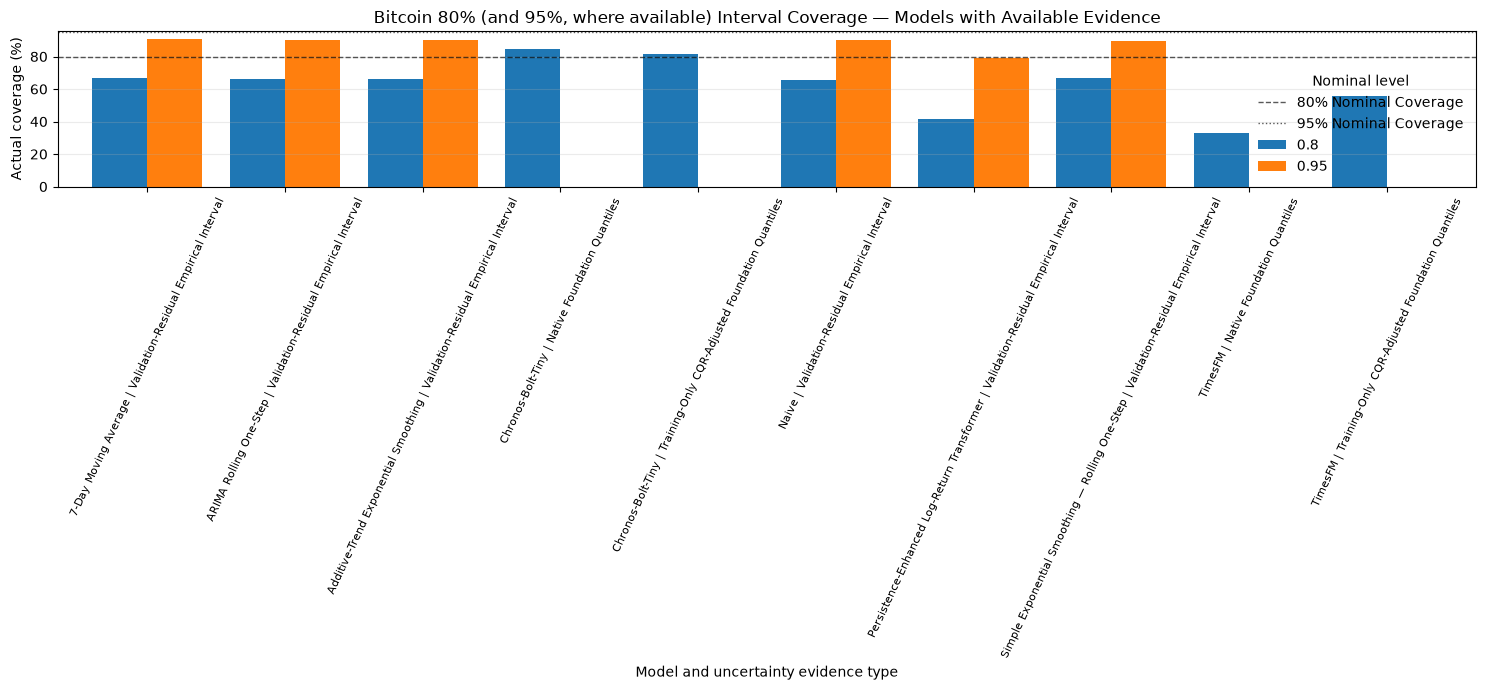

In [7]:
coverage = uncertainty[uncertainty['Coverage'].notna()].copy()
coverage['Series'] = coverage['Model'] + ' | ' + coverage['Uncertainty Evidence Type']
coverage_plot = coverage.pivot(index='Series', columns='Nominal Level', values='Coverage')

ax = (100 * coverage_plot).plot(kind='bar', figsize=(15, 7), width=0.8)
for nominal, style in [(0.80, '--'), (0.95, ':')]:
    ax.axhline(100 * nominal, color='black', linestyle=style, linewidth=1, alpha=0.65,
               label=f'{int(100*nominal)}% Nominal Coverage')
ax.set(title='Bitcoin 80% (and 95%, where available) Interval Coverage — Models with Available Evidence',
       xlabel='Model and uncertainty evidence type', ylabel='Actual coverage (%)')
ax.tick_params(axis='x', rotation=65, labelsize=8)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Nominal level', frameon=False)
ax.figure.tight_layout()
plt.show()

Models with unavailable uncertainty evidence (Persistence-Enhanced Log-Return LSTM, Prophet — 30-Day Periodic Refit) are not shown in this chart -- their absence is a scope limitation, not a coverage value of zero.

## 6.2 CQR Adjustment Interpretation

Chronos has a negative CQR adjustment because its native calibration intervals over-covered on the training calibration window; finite-sample CQR therefore narrows rather than widens them. A negative adjustment is not automatically erroneous -- it reflects that the original native interval was wider than necessary to hit the target nominal coverage on the calibration data. The calibration uses pre-test information only (the 180 training rows ending 2023-08-11); no final-test residual is used to force nominal coverage. Widths are interpreted only within methodologically comparable evidence types (Section 3.2).

# 7. Key Findings

### Evidence Availability

Two models (Chronos-Bolt-Tiny, TimesFM) have native probabilistic evidence, additionally recalibrated with training-only CQR. Six models (Naive, 7-Day Moving Average, ARIMA Rolling One-Step, Simple Exponential Smoothing, Additive-Trend Exponential Smoothing, Persistence-Enhanced Log-Return Transformer) rely on validation-residual empirical intervals. Two models (Persistence-Enhanced Log-Return LSTM, Prophet — 30-Day Periodic Refit) have no authoritative uncertainty evidence.

> The ten-model point-forecast ranking is more complete than the uncertainty evidence set.

### Calibration

Chronos-Bolt-Tiny's native coverage (0.8454) lies close to nominal 80%, and training-only calibration moves it still closer (0.8153). TimesFM's native coverage (0.3308) substantially undercovers; training-only calibration improves it (0.5561) but it remains materially below nominal.

### Accuracy vs Uncertainty

Notebook 07's authoritative point-forecast ranking (read read-only here, not recomputed) places TimesFM ahead of Chronos-Bolt-Tiny on RMSE (rank 6 vs. rank 7 of 10). Chronos, the weaker point forecaster of the two, has substantially better interval calibration on both the native and CQR-adjusted evidence.

> The stronger point forecaster is not automatically the better calibrated probabilistic forecaster.

This is directly relevant to the project's trustworthiness thesis. Chronos is not described as universally "more trustworthy" here -- only that it has stronger uncertainty-calibration evidence on this task, a distinction the point-forecast ranking alone cannot reveal.

# 8. Limitations

### Heterogeneous Evidence
Native quantiles and retrofitted validation-residual intervals are fundamentally different uncertainty mechanisms. Any downstream composite that combines them makes a modelling choice -- it is not a neutral measurement fact.

### Missing Evidence
PE-LSTM and Prophet currently have no authoritative uncertainty evidence. Their absence from coverage figures is not evidence of bad calibration.

### Coverage Figure Is Not a Complete 10-Model View
The Section 6.1 chart omits the two unavailable-evidence models entirely; it is not a full ten-model uncertainty comparison.

### One Nominal Level for Foundation Models
Chronos and TimesFM have coverage evidence only at the 80% nominal level. The six validation-residual empirical-interval models additionally have 95% evidence, so nominal-level coverage is itself asymmetric across evidence types -- this is not full distributional calibration for any model.

### Marginal vs Conditional Coverage
Coverage figures throughout this notebook are marginal across the full test set. No conditional coverage (e.g. coverage broken out by the volatility/movement regimes from Notebook 09) is computed here, so good marginal coverage should not be read as good coverage in every regime.

### Width Comparability
Average interval width is not directly comparable across native, CQR-adjusted, and empirical interval types (Section 3.2) -- a wide empirical-residual interval and a narrow native foundation interval cannot be ranked against each other on width alone.

### Calibration Sample
The foundation-model CQR calibration window is 180 training rows (2023-02-13 to 2023-08-11). The validation-residual empirical-interval calibration window is the final 1,061 training dates -- roughly 5.9x larger. This size difference is not adjusted for anywhere in this notebook.

### Exact Interval Vectors
Per-day lower/upper interval bounds are preserved for the foundation-model methods (`results/foundation_uncertainty_calibration.csv`) but not for the validation-residual empirical-interval methods, which retain only the resulting scalar radius/width. This limits any additional proper scoring-rule analysis (e.g. pinball loss) to the foundation models only, and no such analysis is attempted here.

# 9. Next Notebook

Next: `11_Bitcoin_Statistical_Inference.ipynb`

Notebook 11 moves from uncertainty evidence to inferential comparison of point-forecast loss: pairwise forecast comparison, HAC/Newey-West variance, Holm multiple-testing correction, and practical RMSE differences.